# Stage 4 — Inspect BFTS posteriors over time (school model)

**No ground truth in practice** — we run ONE BFTS replicate and watch the per-arm posteriors **tighten and separate** to judge when we are confident about the top-`m` strategies.

Just press **Run → Run All Cells**. The 4-panel figure appears below the last cell.

In [1]:
import import_bfts
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt

from environments.csv_dist import csv_dist_bandit, csv_dist_means
from algorithms.bfts import BFTS
from algorithms.posteriors.t_distribution import TDistribution

CSV = "brute-force-reward.csv"
SEED, M, TOTAL, ALPHA = 1, 2, 2000, 0.0   # m-top=2, 2000 pulls, Jeffreys prior (alpha=0 -> T posterior)
np.random.seed(SEED)

bandit = csv_dist_bandit(CSV)
means  = np.array(csv_dist_means(CSV))    # ground truth (only used to label; pretend unknown)
N = len(bandit.arms)
posts = [TDistribution(ALPHA) for _ in range(N)]
algo  = BFTS(bandit, M, posts)

# the posterior density given in the assignment (Student-t)
def pdf(x, posterior, rewards):
    n = len(rewards); freedom = posterior.freedom(n)
    sigma = np.sqrt(np.var(rewards) / freedom); mu = np.mean(rewards)
    return sp.t.pdf((x - mu) / sigma, freedom) / sigma

print("number of arms:", N)

number of arms: 72


In [2]:
# 1) initialise each arm with the minimum pulls its posterior needs
for i in range(N):
    for _ in range(posts[i].times_to_init()):
        algo.add_reward(i, bandit.play(i))
pulls = sum(posts[i].times_to_init() for i in range(N))   # = 3 * 72 = 216

# 2) run BFTS, snapshotting the rewards-per-arm at chosen pull counts
SNAPS = [pulls, 500, 1000, TOTAL]
captured = {pulls: [list(r) for r in algo.rewards_per_arm]}
t = 0
while pulls < TOTAL:
    t += 1
    algo.step(t)            # boundary-focused TS: sample each arm, pull the one at the top-m boundary
    pulls += 1
    if pulls in SNAPS:
        captured[pulls] = [list(r) for r in algo.rewards_per_arm]
print("snapshots taken at pulls:", sorted(captured))

snapshots taken at pulls: [216, 500, 1000, 2000]


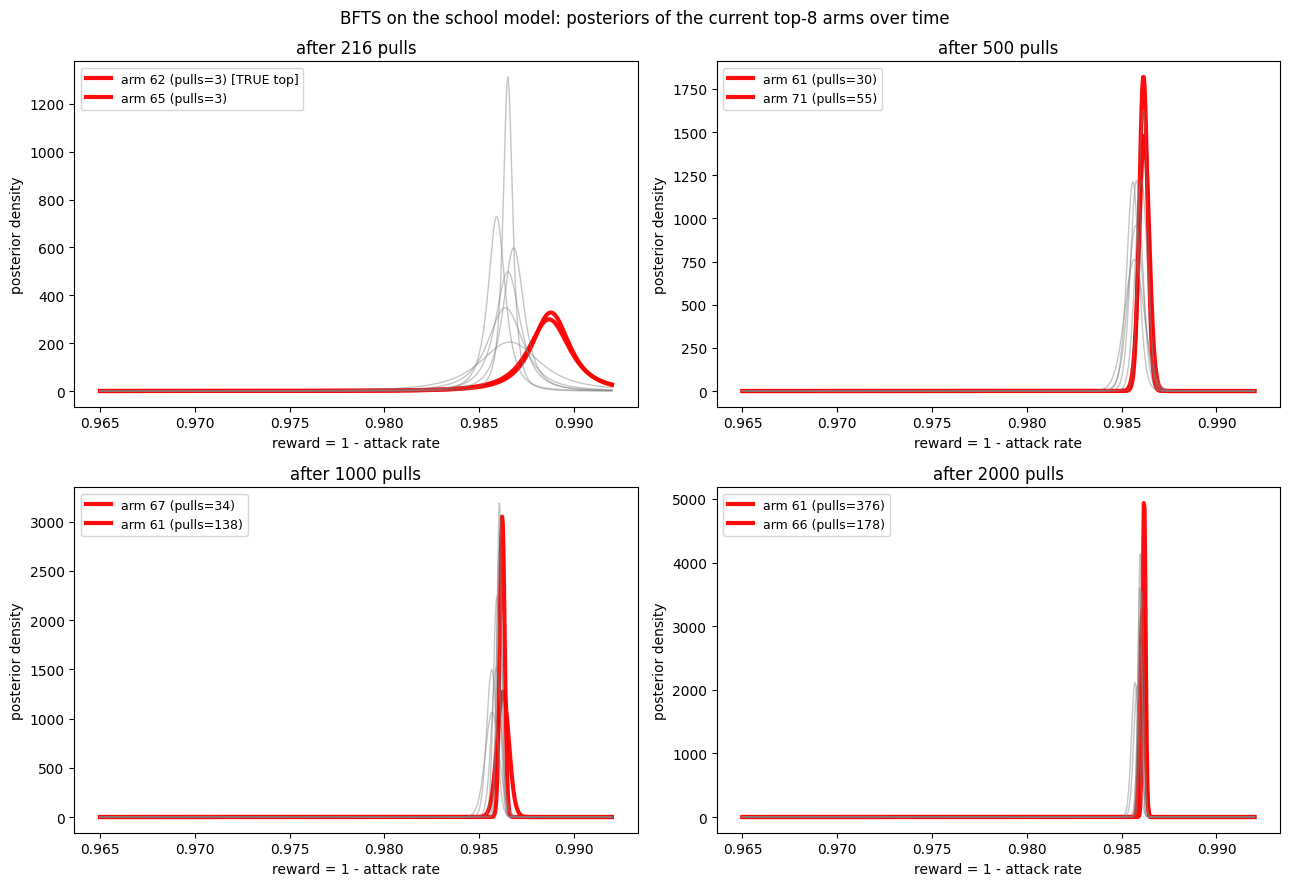

TRUE top-2 arms: [60, 62]
BFTS top-2 arms: [61, 66]
most-pulled (pulls, arm): [(376, 61), (307, 71), (254, 65), (237, 62), (178, 66), (135, 67)]
arms left at only 3 init pulls: 17 of 72


In [3]:
# 3) plot the posteriors of the current top-8 arms at each snapshot
true_top = set(np.argsort(-means)[:M])
xs = np.linspace(0.965, 0.992, 700)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, tp in zip(axes.ravel(), sorted(captured)):
    rew = captured[tp]
    pmean = np.array([np.mean(r) if len(r) >= 2 else -1 for r in rew])
    cur_top = set(np.argsort(-pmean)[:M])
    for arm in np.argsort(-pmean)[:8]:
        r = rew[arm]
        if len(r) < 2:
            continue
        top = arm in cur_top
        ax.plot(xs, pdf(xs, posts[arm], r),
                lw=(3 if top else 1), alpha=(0.95 if top else 0.45),
                color=('red' if top else 'gray'),
                label=(f"arm {arm} (pulls={len(r)})" + (" [TRUE top]" if arm in true_top else "")) if top else None)
    ax.set_title(f"after {tp} pulls")
    ax.set_xlabel("reward = 1 - attack rate")
    ax.set_ylabel("posterior density")
    ax.legend(fontsize=9)
plt.suptitle("BFTS on the school model: posteriors of the current top-8 arms over time")
plt.tight_layout()
plt.show()

print("TRUE top-%d arms:" % M, sorted(true_top))
print("BFTS top-%d arms:" % M, sorted(np.argsort(-np.array([np.mean(r) for r in algo.rewards_per_arm]))[:M]))
print("most-pulled (pulls, arm):", sorted(((len(r), i) for i, r in enumerate(algo.rewards_per_arm)), reverse=True)[:6])
print("arms left at only %d init pulls:" % posts[0].times_to_init(),
      sum(1 for r in algo.rewards_per_arm if len(r) == posts[0].times_to_init()), "of", N)